# RalphGuard Candidate-v2 — Training & Validation Notebook

Notebook นี้อธิบายขั้นตอนตั้งแต่ข้อมูลดิบ การตรวจสอบ molecular identity การสร้าง features การเทรน ensemble ไปจนถึงการตรวจสอบความแม่นยำ โดยอ่านผลจาก Candidate-v2 ล่าสุดโดยไม่แก้ Production model

**ผลการเทรนล่าสุด:** 4 endpoints, 10,774 unique endpoint-molecule rows, exact train/external overlap = 0

> หมายเหตุ: RalphGuard เป็นเครื่องมือคัดกรอง in-silico ไม่ใช่ผลทดแทนการทดสอบมาตรฐานหรือการประเมินโดยผู้เชี่ยวชาญ

## ภาพรวม Algorithm

![RalphGuard training pipeline](../scientific/models/candidate_v2/plots/00_algorithm_pipeline.png)

In [28]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'data_prep.py').exists() and (candidate / 'docker-compose.yml').exists():
            return candidate
    raise FileNotFoundError('เปิด Notebook จากภายใน RalphGuard repository')

ROOT = find_project_root(Path.cwd())
MODEL_DIR = ROOT / 'scientific' / 'models' / 'candidate_v2'
PLOTS_DIR = MODEL_DIR / 'plots'
REPORT_PATH = MODEL_DIR / 'validation_report.json'
INTEGRITY_PATH = ROOT / 'scientific' / 'models' / 'training_integrity_report.json'

print('Project root:', ROOT)
print('Candidate report exists:', REPORT_PATH.exists())
print('Integrity report exists:', INTEGRITY_PATH.exists())

Project root: C:\Users\suraw\Documents\GitHub\ralphguard
Candidate report exists: True
Integrity report exists: True


## ขั้นตอนที่ 1 — ข้อมูลที่ใช้และ Integrity Audit

ข้อมูลหลักมาจาก ICE experimental/reference evidence และเสริมด้วย PubChem regulatory weak labels ที่มีแหล่งอ้างอิง ก่อนเทรนจะตรวจโครงสร้าง, label, exact identity, evidence tier, same-tier conflicts, duplicates และ external holdout leakage โดย lower-tier conflict จะไม่ลบ experimental label ที่คุณภาพสูงกว่า

In [37]:
integrity = json.loads(INTEGRITY_PATH.read_text(encoding='utf-8'))
summary = integrity['summary']
display(pd.Series(summary, name='value').to_frame())

audit_rows = []
for endpoint, payload in integrity['endpoints'].items():
    training = payload['training']
    external = payload.get('external', {})
    audit_rows.append({
        'endpoint': endpoint,
        'raw_rows': training['raw_rows'],
        'invalid_structure': training['invalid_structure_rows'],
        'conflicting_identity': training['conflicting_identity_count'],
        'external_holdout_quarantined': training['external_holdout_identities_quarantined'],
        'clean_training_molecules': training['clean_training_identity_count'],
        'positive': training['positive'],
        'negative': training['negative'],
        'external_n': external.get('external_unique_identities', 0),
        'exact_overlap': external.get('exact_identity_overlap', 'not provided'),
    })
audit_table = pd.DataFrame(audit_rows).set_index('endpoint')
display(audit_table)
print('Total clean training rows:', int(audit_table['clean_training_molecules'].sum()))

,value
audited_endpoints,4
missing_endpoints,[]
conflicting_identity_count,28
clean_training_endpoint_rows,10774
external_holdout_identities_quarantined_from_training,14
minimum_training_endpoint_rows_requested,10000
minimum_training_endpoint_rows_met,True
external_exact_overlap_count,0
ready_for_retraining,True
independent_external_validation_ready,False


,raw_rows,invalid_structure,conflicting_identity,external_holdout_quarantined,clean_training_molecules,positive,negative,external_n,exact_overlap
endpoint,,,,,,,,,
skin,399,11,3,5,373,310,63,7,0.0
eye,527,1,1,0,514,487,27,0,NaN
sens,1550,0,6,4,1510,643,867,9,0.0
acute,8868,185,18,5,8377,4827,3550,8,0.0


Total clean training rows: 10774


### Data profile หลัง Clean และ Deduplicate

<table><tr><td><img src="../scientific/models/candidate_v2/plots/skin/01_data_profile.png" width="520"></td><td><img src="../scientific/models/candidate_v2/plots/eye/01_data_profile.png" width="520"></td></tr><tr><td><img src="../scientific/models/candidate_v2/plots/sens/01_data_profile.png" width="520"></td><td><img src="../scientific/models/candidate_v2/plots/acute/01_data_profile.png" width="520"></td></tr></table>

## ขั้นตอนที่ 2 — Molecular Identity

1. RDKit parse โครงสร้างจาก SMILES
2. แปลงเป็น canonical isomeric SMILES
3. ใช้ InChIKey เป็น exact molecular identity หลัก
4. แยก external holdout ออกจาก training ก่อน conflict handling
5. ตัด identity ที่มีทั้ง label 0 และ 1 ออกเพื่อรอตรวจสอบ
6. เหลือหนึ่งแถวต่อ exact molecule ตาม evidence-priority policy

In [30]:
from rdkit import Chem

example_smiles = 'CC(=O)OC1=CC=CC=C1C(=O)O'  # aspirin
molecule = Chem.MolFromSmiles(example_smiles)
canonical_smiles = Chem.MolToSmiles(molecule, canonical=True, isomericSmiles=True)
inchi = Chem.MolToInchi(molecule)
inchikey = Chem.InchiToInchiKey(inchi)
pd.DataFrame([{
    'input_smiles': example_smiles,
    'canonical_smiles': canonical_smiles,
    'inchikey': inchikey,
}])

,input_smiles,canonical_smiles,inchikey
0,CC(=O)OC1=CC=CC=C1C(=O)O,CC(=O)Oc1ccccc1C(=O)O,BSYNRYMUTXBXSQ-UHFFFAOYSA-N


## ขั้นตอนที่ 3 — Feature Engineering

- **Skin / Eye:** MACCS structural keys + molecular descriptors
- **Sensitization:** Morgan circular fingerprint
- **Acute toxicity:** Morgan + MACCS + molecular descriptors

Fingerprint แทน substructures เป็นเวกเตอร์ ส่วน descriptors เช่น molecular weight, LogP และจำนวน donor/acceptor ช่วยบอกสมบัติทางกายภาพเคมี

In [31]:
sys.path.insert(0, str(ROOT / 'scientific'))
from featurizer import featurize_mol

feature_modes = ['maccs_descr', 'morgan', 'morgan_maccs_descr']
feature_demo = []
for mode in feature_modes:
    vector = np.asarray(featurize_mol(molecule, mode))
    feature_demo.append({
        'feature_mode': mode,
        'dimensions': int(vector.size),
        'non_zero_values': int(np.count_nonzero(vector)),
    })
pd.DataFrame(feature_demo)

,feature_mode,dimensions,non_zero_values
0,maccs_descr,177,31
1,morgan,2048,24
2,morgan_maccs_descr,2225,55


## ขั้นตอนที่ 4 — Soft-voting Ensemble

โมเดลประกอบด้วย Random Forest, Extra Trees, Logistic Regression และ HistGradientBoosting จากนั้นเฉลี่ย probability ของสมาชิกทั้งสี่ตัว การใช้โมเดลหลายชนิดช่วยลดการพึ่งพา inductive bias ของ algorithm ตัวเดียว

Class weighting ใช้ลดผลจากข้อมูลไม่สมดุล และ threshold ถูกเลือกด้วย Youden's J จาก training-fold predictions เท่านั้น

In [32]:
sys.path.insert(0, str(ROOT))
import data_prep

data_prep.configure_training_profile('standard')
members = data_prep.build_members()
pd.DataFrame({
    'member': data_prep.MEMBER_NAMES,
    'estimator': [type(model).__name__ for model in members],
    'configuration': [str(model) for model in members],
})

,member,estimator,configuration
0,RandomForest,RandomForestClassifier,RandomForestClassifier(class_weight='balanced'...
1,ExtraTrees,ExtraTreesClassifier,"ExtraTreesClassifier(class_weight='balanced', ..."
2,LogReg,Pipeline,"Pipeline(steps=[('standardscaler', StandardSca..."
3,HistGB,HistGradientBoostingClassifier,HistGradientBoostingClassifier(random_state=42)


## ขั้นตอนที่ 5 — Validation Protocol

- **OOF 5-fold:** ทุกโมเลกุลถูกทำนายโดยโมเดลที่ไม่เห็นโมเลกุลนั้นตอน fit
- **Nested CV:** เลือก threshold ภายใน outer-training fold ป้องกัน threshold leakage
- **Scaffold CV:** แยก Bemis–Murcko scaffold ระหว่าง train/test เพื่อวัดการทำนาย structural family ใหม่
- **External:** ใช้เฉพาะชุดภายนอกที่ exact identity overlap กับ training เท่ากับศูนย์

Acute ใช้ large validation profile จึงงด Nested CV เพื่อจำกัดเวลาและทรัพยากร แต่ยังมี OOF และ Scaffold CV

In [33]:
report = json.loads(REPORT_PATH.read_text(encoding='utf-8'))
metric_rows = []
for endpoint, payload in report['endpoints'].items():
    external = payload['external']
    external_metrics = external.get('metrics', {})
    metric_rows.append({
        'endpoint': endpoint,
        'n': payload['dataset']['n'],
        'positive': payload['dataset']['positive'],
        'negative': payload['dataset']['negative'],
        'OOF_AUC': payload['candidate_oof'].get('auc'),
        'OOF_MCC': payload['candidate_oof'].get('mcc'),
        'Nested_AUC': payload['candidate_nested_stratified'].get('auc'),
        'Scaffold_AUC': payload['candidate_scaffold_grouped'].get('auc'),
        'Scaffold_MCC': payload['candidate_scaffold_grouped'].get('mcc'),
        'External_status': external.get('status'),
        'External_n': external_metrics.get('n_pos', 0) + external_metrics.get('n_neg', 0),
        'External_AUC': external_metrics.get('auc'),
        'External_MCC': external_metrics.get('mcc'),
    })
metrics_table = pd.DataFrame(metric_rows).set_index('endpoint')
display(metrics_table.round(3))

,n,positive,negative,OOF_AUC,OOF_MCC,Nested_AUC,Scaffold_AUC,Scaffold_MCC,External_status,External_n,External_AUC,External_MCC
endpoint,,,,,,,,,,,,
skin,373,310,63,0.862,0.473,0.862,0.825,0.340,complete,7,0.667,0.548
eye,514,487,27,0.808,0.278,0.808,0.769,0.251,not_provided,0,NaN,NaN
sens,1510,643,867,0.927,0.726,0.927,0.899,0.675,complete,9,0.800,0.060
acute,8377,4827,3550,0.858,0.543,NaN,0.827,0.477,complete,8,0.938,0.775


### แสดงผลแต่ละ Validation Stage

เปลี่ยน `ENDPOINT` เป็น `skin`, `eye`, `sens` หรือ `acute` แล้วรันเซลล์ด้านล่าง กราฟทุกภาพมี prediction CSV รองรับอยู่ในโฟลเดอร์เดียวกัน

### Stage 1 — Data profile

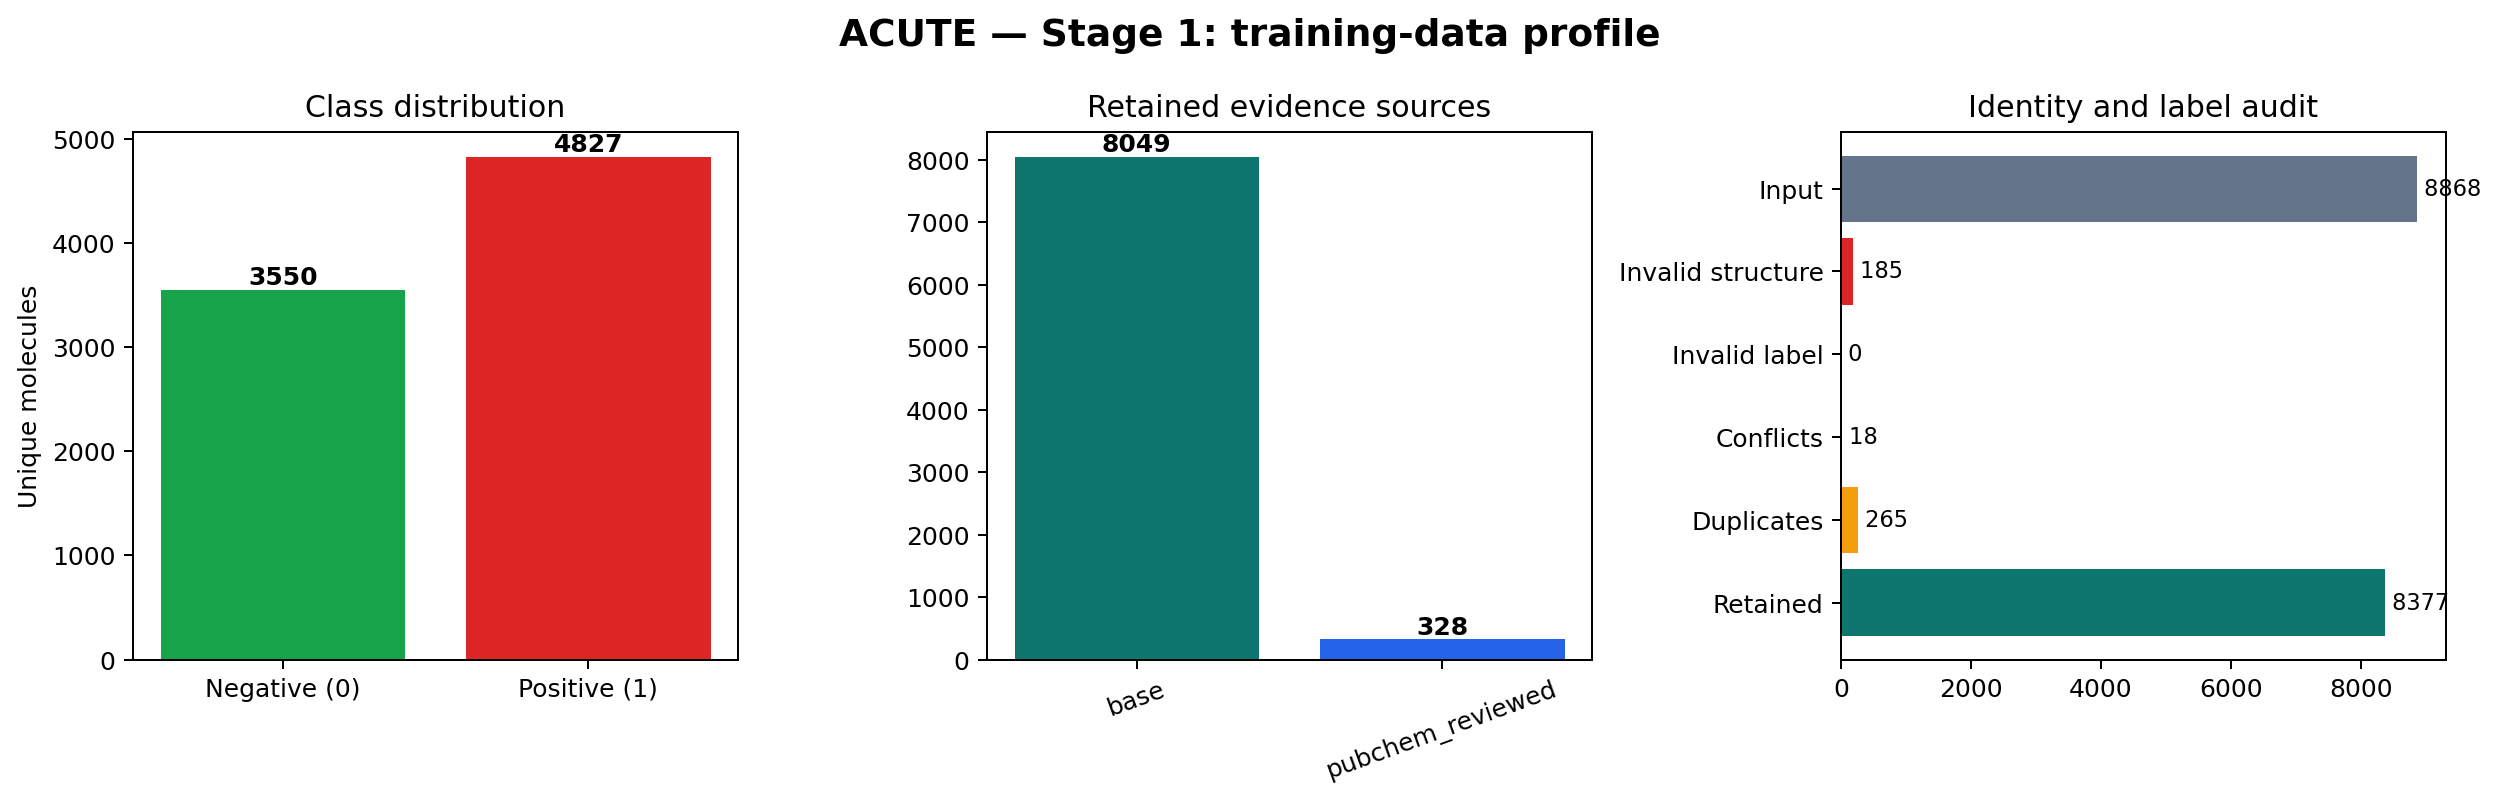

### Stage 2 — OOF validation

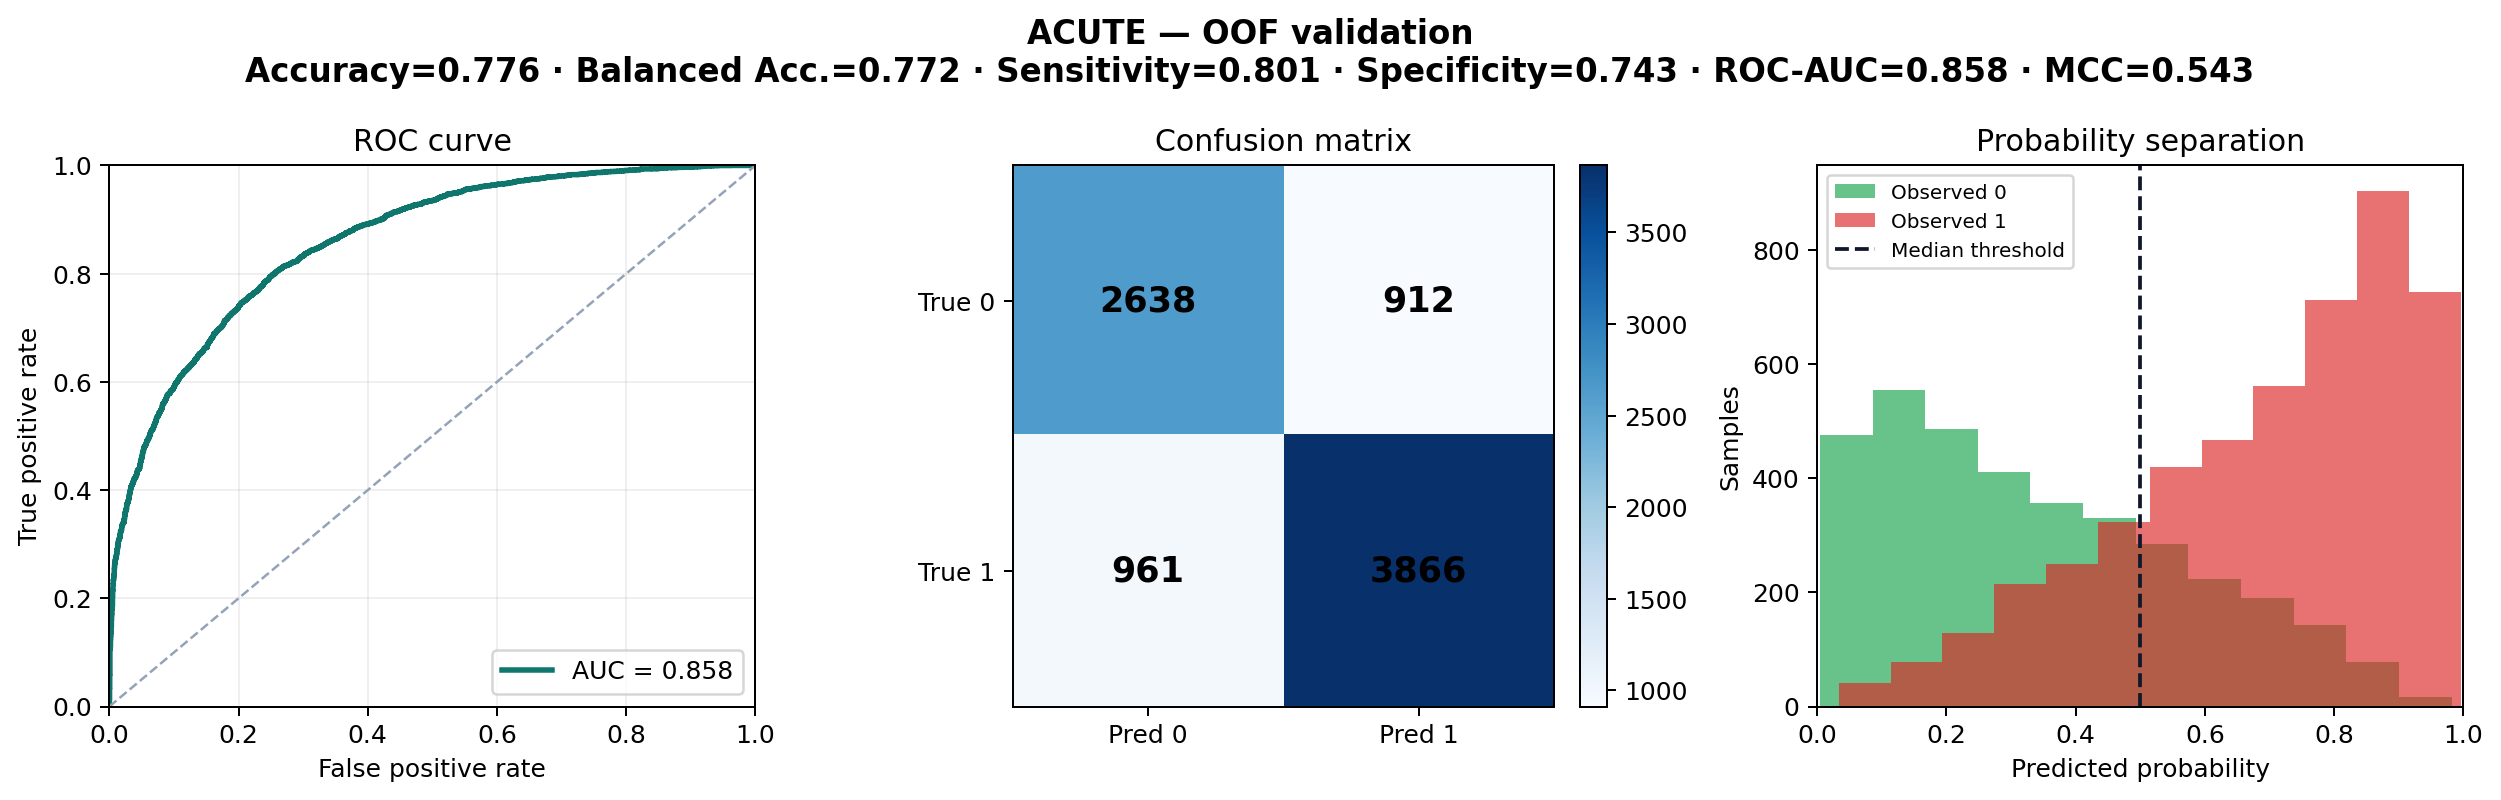

### Stage 3 — Nested CV

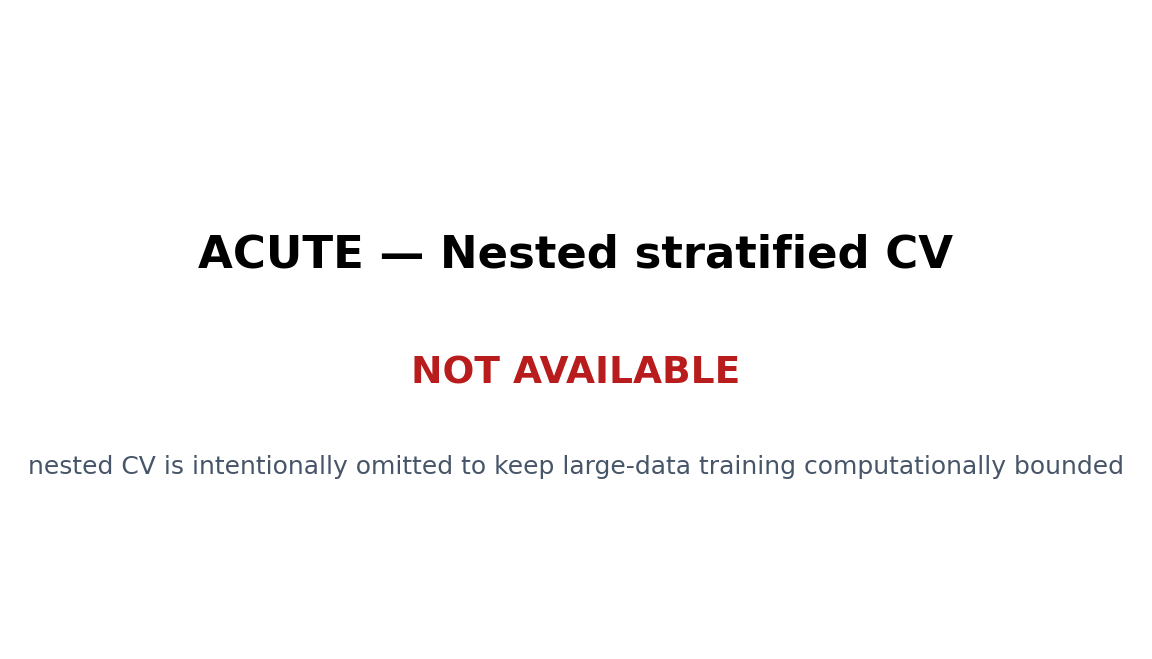

### Stage 4 — Scaffold CV

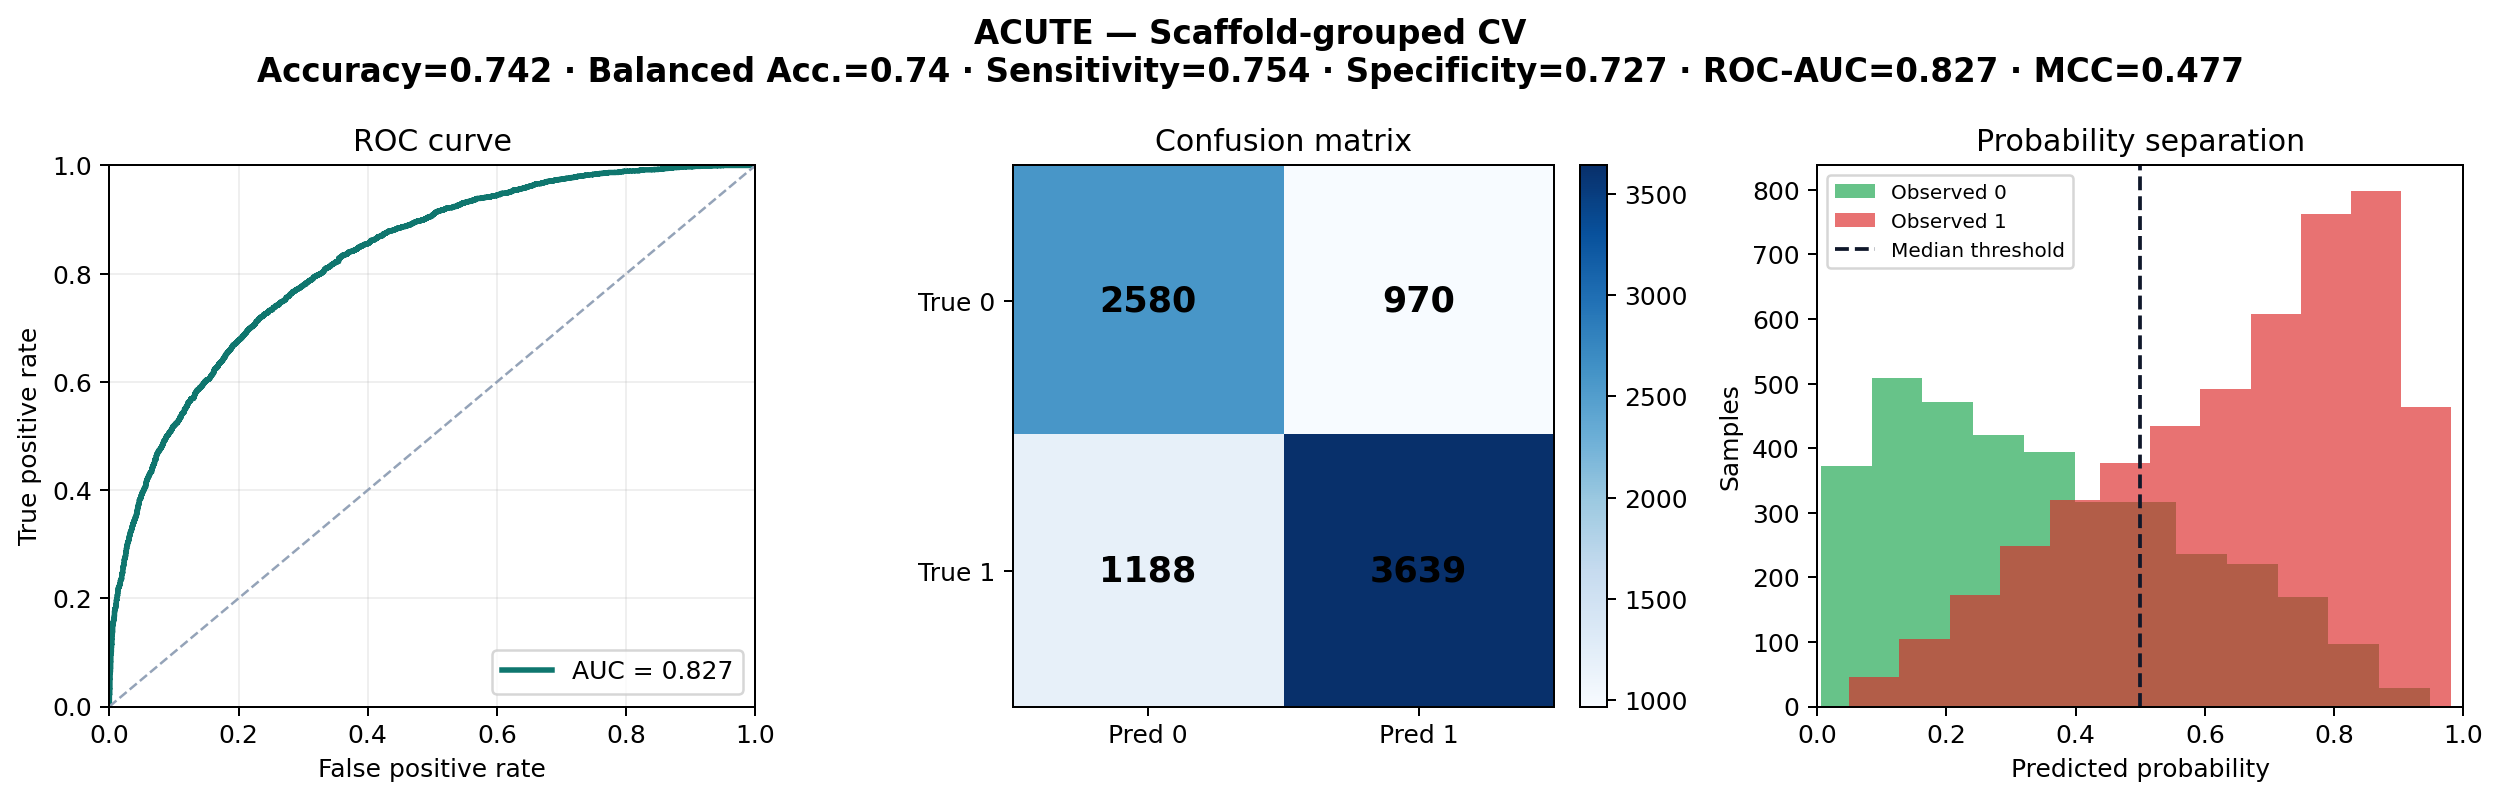

### Stage 5 — External validation

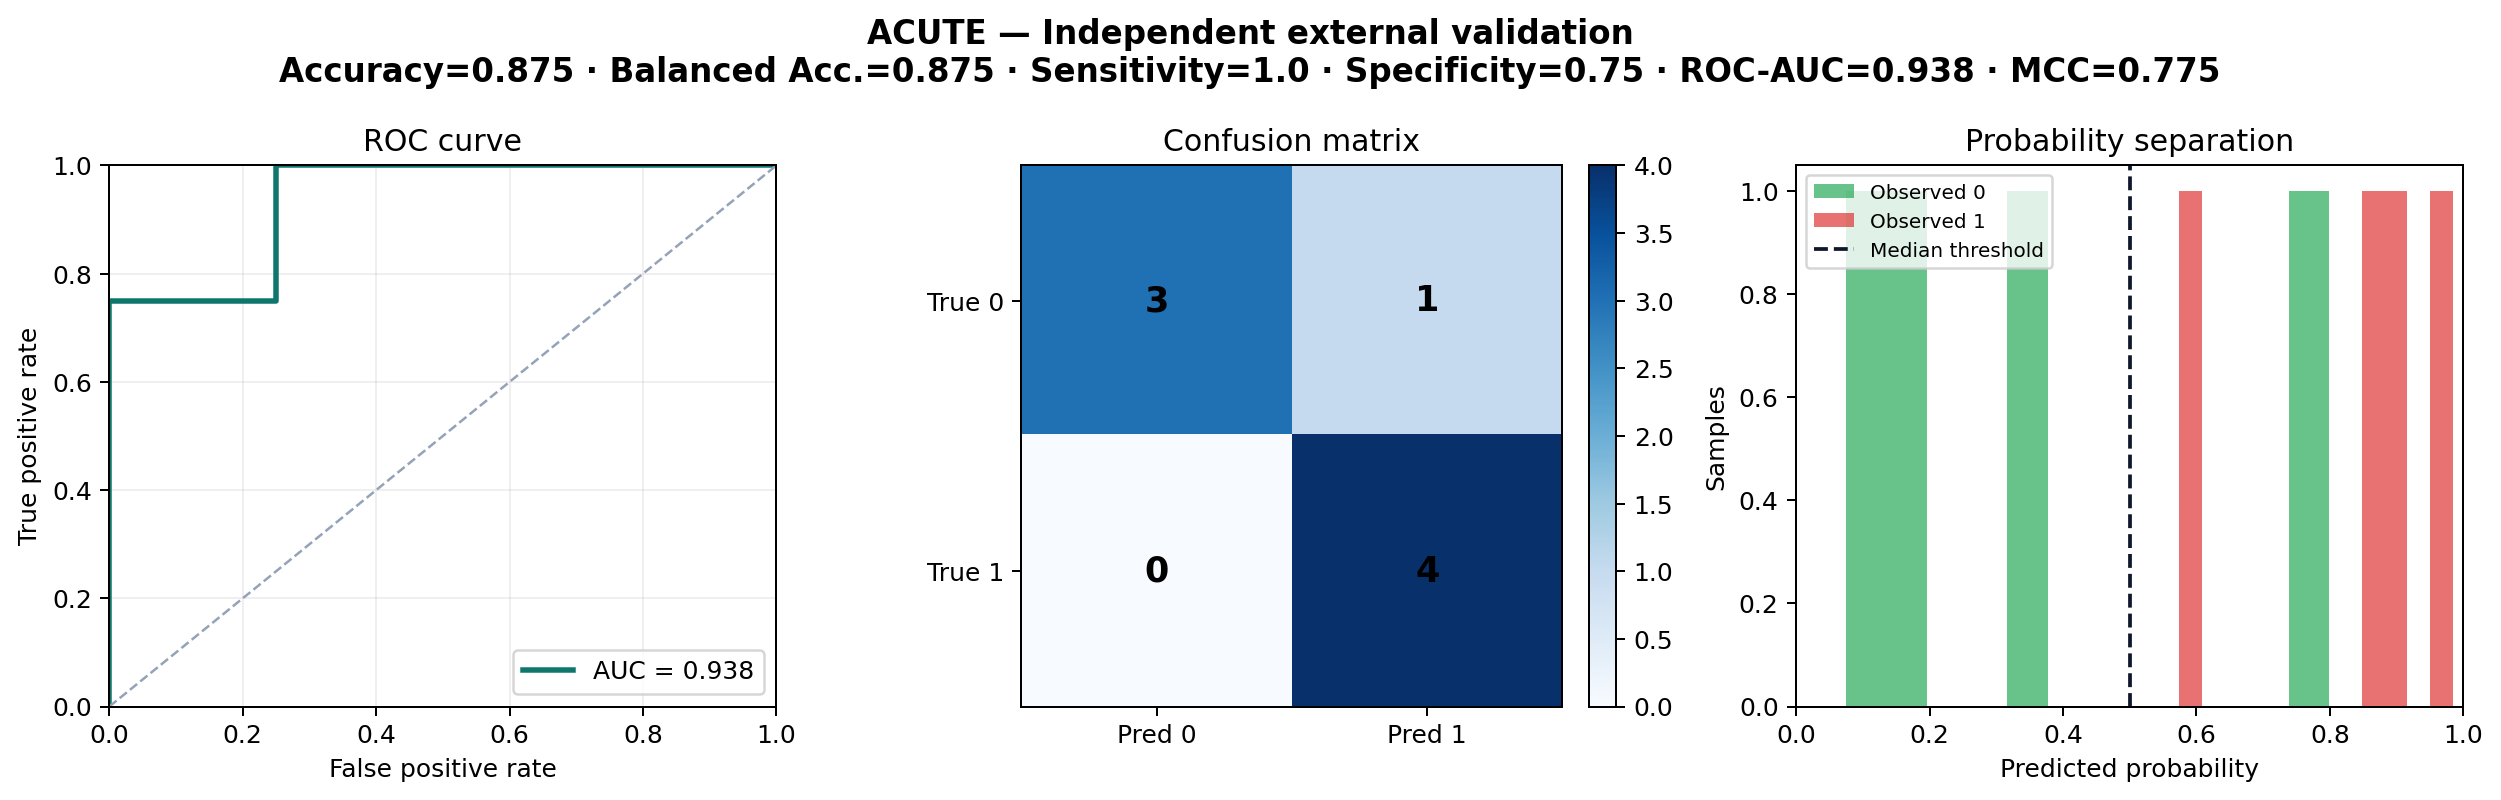

### Stage 6 — Model comparison

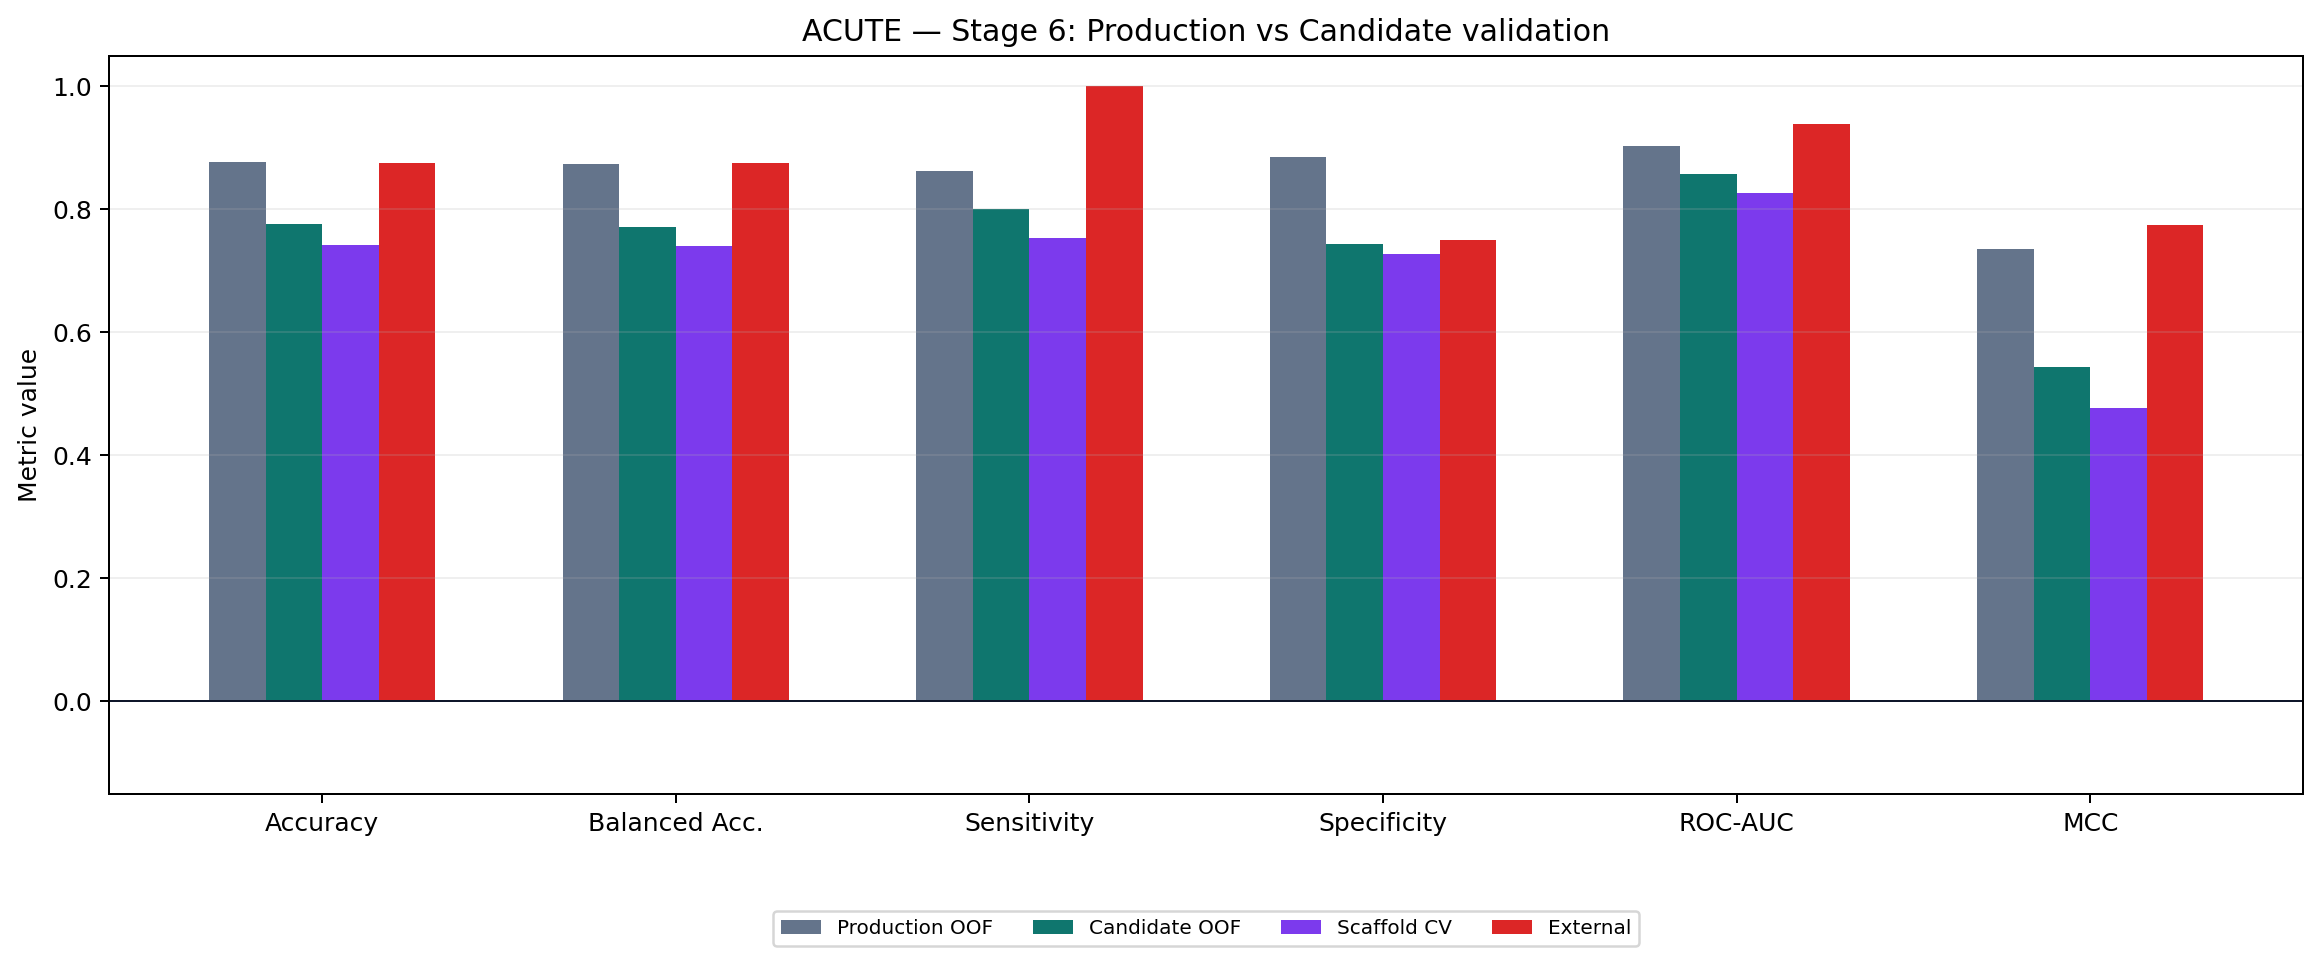

In [34]:
ENDPOINT = 'acute'
assert ENDPOINT in {'skin', 'eye', 'sens', 'acute'}

plot_stages = [
    ('Stage 1 — Data profile', '01_data_profile.png'),
    ('Stage 2 — OOF validation', '02_oof_validation.png'),
    ('Stage 3 — Nested CV', '03_nested_cv.png'),
    ('Stage 4 — Scaffold CV', '04_scaffold_cv.png'),
    ('Stage 5 — External validation', '05_external_validation.png'),
    ('Stage 6 — Model comparison', '06_model_comparison.png'),
    ('Stage 7 — Evidence-origin validation', '07_evidence_origin_validation.png'),
]
for title, filename in plot_stages:
    display(Markdown(f'### {title}'))
    display(Image(filename=str(PLOTS_DIR / ENDPOINT / filename), width=1100))

## ขั้นตอนที่ 6 — เปรียบเทียบ Candidate กับ Production

ค่าด้านล่างเป็นความต่างของ metric style เดียวกัน แต่ชุดข้อมูล Candidate มีขนาดและ distribution ต่างจาก Production รุ่นเก่า จึงไม่ควรใช้ delta เพียงอย่างเดียวเพื่อตัดสินใจ promote

In [35]:
delta_rows = []
for endpoint, payload in report['endpoints'].items():
    delta_rows.append({'endpoint': endpoint, **payload['candidate_oof_minus_production_oof']})
display(pd.DataFrame(delta_rows).set_index('endpoint').round(3))
print('Promotion status:', report['promotion_status'])
print('Production models modified:', report['production_models_modified'])

,accuracy,balanced_accuracy,sensitivity,specificity,auc,mcc
endpoint,,,,,,
skin,-0.083,-0.110,-0.137,-0.083,-0.064,-0.303
eye,0.046,-0.087,-0.022,-0.153,-0.078,-0.345
sens,0.064,0.038,-0.051,0.128,0.031,0.106
acute,-0.101,-0.101,-0.061,-0.142,-0.045,-0.193


Promotion status: manual_review_required
Production models modified: False


## Optional — สั่งเทรนใหม่จาก Notebook

ค่าเริ่มต้นปิดไว้เพื่อไม่ให้กด Run All แล้วเสียเวลาโดยไม่ตั้งใจ

- `RUN_CANDIDATE_ONLY=True` ใช้ข้อมูลที่เตรียมไว้แล้วและเทรน Candidate ใหม่
- Full quality pipeline ต่อ PubChem จาก page 201, audit เป้า 10k/endpoint และเทรนทั้งหมด ให้รัน `./scripts/train_quality_10k_per_endpoint.ps1` จาก PowerShell เพราะต้องใช้ Docker services

In [36]:
RUN_CANDIDATE_ONLY = False
VALIDATION_PROFILE = 'auto'  # auto | full | large | quick
MAX_TRAINING_ROWS_PER_ENDPOINT = 15000

if RUN_CANDIDATE_ONLY:
    command = [
        sys.executable,
        str(ROOT / 'scripts' / 'train_candidate_v2.py'),
        '--validation-profile', VALIDATION_PROFILE,
        '--max-training-rows-per-endpoint', str(MAX_TRAINING_ROWS_PER_ENDPOINT),
    ]
    print('Running:', ' '.join(command))
    subprocess.run(command, cwd=ROOT, check=True)
else:
    print('Training skipped. Set RUN_CANDIDATE_ONLY=True when you intentionally want to retrain.')

Training skipped. Set RUN_CANDIDATE_ONLY=True when you intentionally want to retrain.


## สรุปและข้อจำกัด

- ตรวจ `training_integrity_report.json` ทุกครั้ง: `ready_for_retraining` คือ hard gate ส่วน `recommended_class_minimum_met` คือ quality target ที่เข้มกว่า
- Accuracy รวมอาจสูงผิดธรรมชาติเมื่อ PubChem weak-positive rows มีจำนวนมาก จึงต้องดู Balanced Accuracy, MCC, Specificity, Scaffold CV และกราฟแยกตาม evidence origin
- Eye ยังเป็น evidence-limited endpoint และยังไม่มี independent external set
- External set ปัจจุบันมีขนาดเล็ก จึงต้องรายงาน uncertainty และห้ามเรียก internal OOF ว่า independent validation
- สถานะที่เหมาะสมคือ **Candidate for manual review** จนกว่าจะมี external validation ที่เป็นอิสระ ครอบคลุมทั้ง 4 endpoints และมีสอง class เพียงพอ